# Residual study

`scp fermi:kerr/toby_files/toby_v3.* files/kerr

In [13]:
%reset -f
%run pylib/tools dark date
from pylib import pixel_table; reload(pixel_table)
from pylib.kerr_funcs import *
pixel_table = PixelTable('files/kerr/toby_v4')

<h5 style="text-align:right; margin-right:15px"> 2026-03-25 08:50</h5>

Loaded pixel table from "files/kerr/toby_v4.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


## plot residuals for 1.33 GeV 

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x706cd8eaafe0>
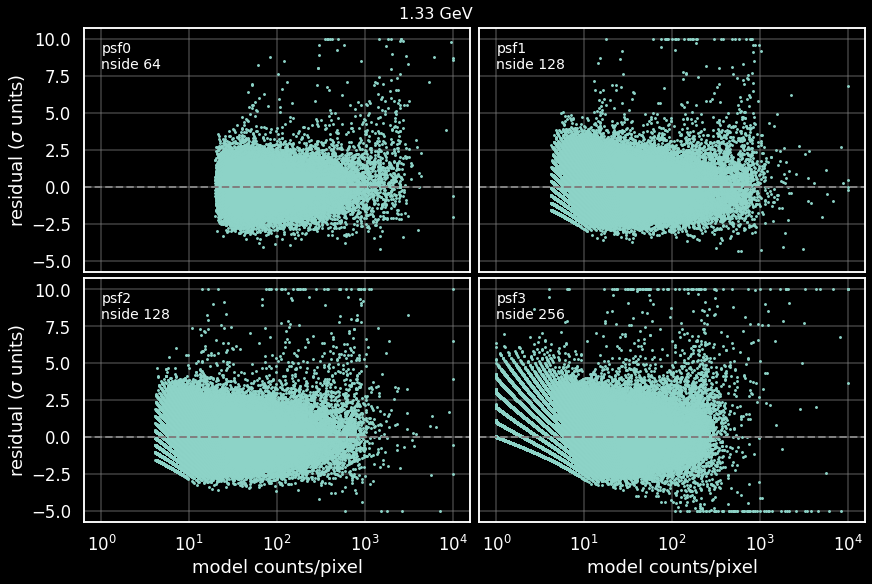

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x706cda7059f0>
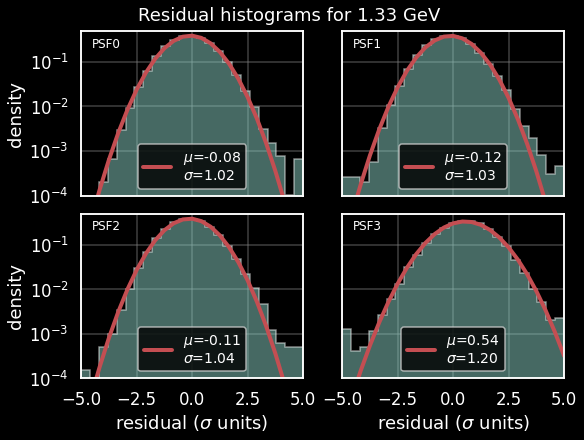

In [14]:
show(f'## plot residuals for {pixel_table(0,(energy_index:=4)).energy} ')
show_fig(plot_residuals_for_given_energy,pixel_table, energy_index)   
show_fig(histograms_of_residuals_for_given_energy,pixel_table, energy_index)

In [17]:
# reload(kerr_funcs); from pylib.kerr_funcs import ResidualPoints
self = ResidualPoints(pixel_table, energy_index=energy_index)

self.df.describe()

,pixel,data,model,sigma,glon,glat,psf,nside
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,318337.590674,1481.015544,1279.381656,6.878304,-6.552848,3.842696,2.647668,228.808290
std,227771.687592,4611.687461,4186.933679,4.001775,108.327973,41.597196,0.835543,59.358459
min,3967.000000,6.000000,0.912907,5.000769,-175.429688,-86.161712,0.000000,64.000000
25%,93963.000000,10.000000,1.924460,5.191649,-97.382812,-30.345183,3.000000,256.000000
50%,301118.000000,55.000000,25.733439,5.580551,-2.460938,1.193748,3.000000,256.000000
75%,496773.000000,571.000000,459.618968,6.942300,88.769531,32.619842,3.000000,256.000000
max,764128.000000,39815.000000,38595.945845,38.631588,179.648438,83.417689,3.000000,256.000000


In [18]:
self.clusterer()
self.cldf

,glon,glat,data,model,sigma,n,ids
0,85.000,83.418,218,148.5,5.7,8,"[0, 38, 37, 36, 35, 22, 21, 12]"
1,-38.672,17.270,1323,988.1,10.7,11,"[1, 92, 91, 90, 89, 28, 27, 26, 15, 14, 2]"
2,-164.883,4.182,17908,16389.9,11.9,12,"[3, 104, 6, 5, 103, 102, 101, 100, 99, 29, 16, 4]"
3,-96.328,-2.687,39815,38595.9,6.2,8,"[7, 133, 9, 131, 129, 127, 30, 8]"
4,127.969,-30.692,165,109.0,5.4,7,"[10, 154, 153, 152, 151, 33, 32]"
5,-71.250,-63.448,93,52.8,5.5,2,"[11, 182]"
6,99.844,-31.039,74,35.8,6.4,4,"[18, 157, 156, 19]"
7,-160.714,78.468,240,163.0,6.0,2,"[41, 43]"
8,49.821,64.199,9,1.9,5.2,2,"[48, 49]"
9,63.457,41.014,100,59.3,5.3,2,"[69, 70]"


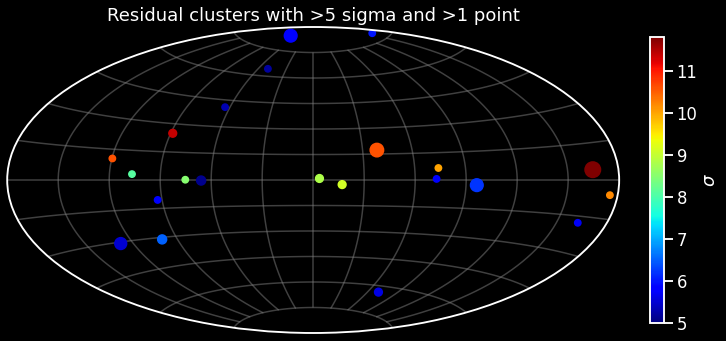

In [ ]:
self.ait_cluster_plot()

In [19]:
from utilities.catalogs import UWcat, Fermi4FGL
show(f""" ## Compare with {(fglname:='uw1617')}""")
fgl = Fermi4FGL(fglname)
# for test in ResidualPoints(pixel_table(1,4)).points:
#     t  = fgl.catalog_entry(test, 1)
#     if t is not None:
#         print(t.name, round(t.ts),  round(t.sep,1))

## Compare with uw1617

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x706ceab4c460>
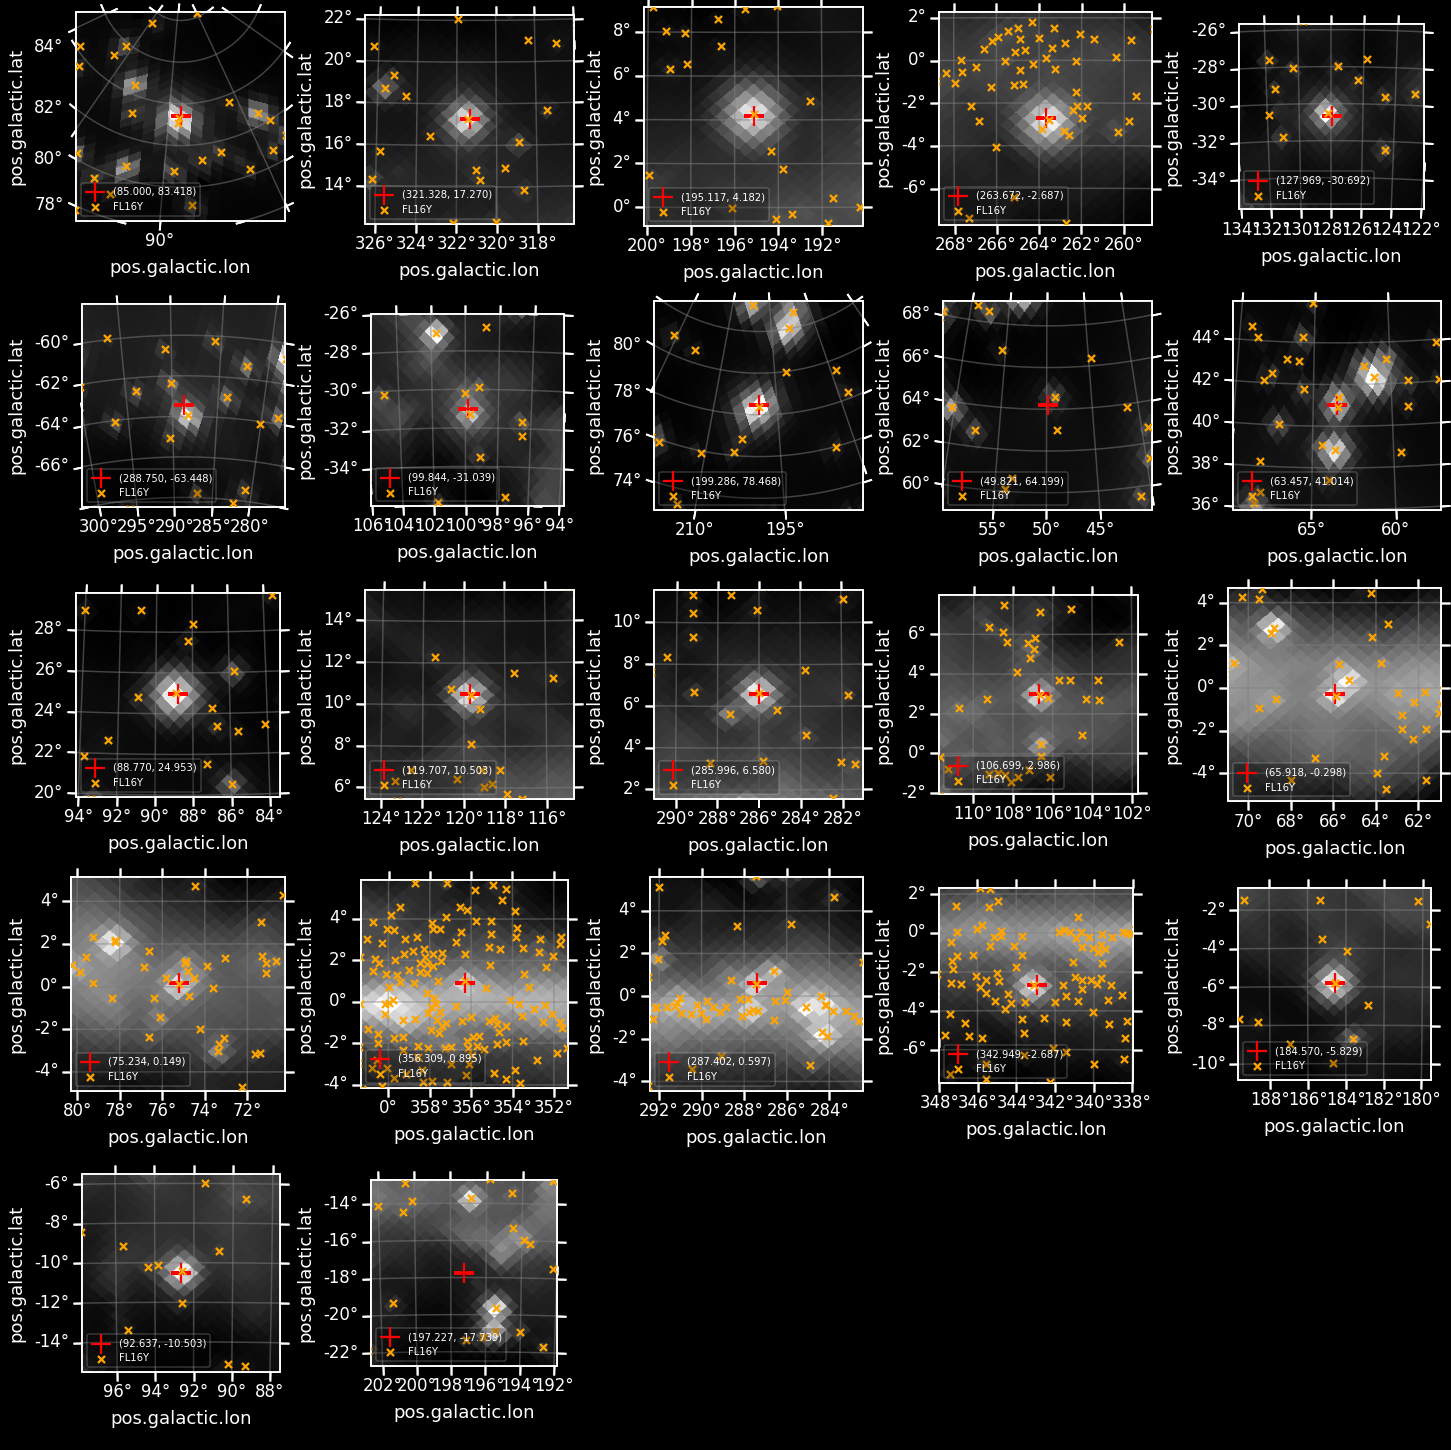

In [ ]:
def residual_scatter(center, band,  fgl,*, component='model', fig=None, figsize=(8,8),**kwargs):
    
    (band.zea_plot(center=center, component=component, size=10, cmap='gist_gray',title='',
        fig=fig,figsize=figsize,  **kwargs)  
        .scatter(center,marker='+',color='red',s=400, 
                label=f'({center.l.deg:.3f}, {center.b.deg:.3f})')
        .scatter(fgl, marker='x',s=50, color='orange', label='FL16Y')
        .legend(loc='lower left',fontsize=10, framealpha=0.25)
    )
    if fig is not None: plt.gca().set(xlabel='',ylabel='', yticklabels=[], xticklabels=[])
    if fig is None: plt.show()


band = pixel_table(2,energy_index)
fig = plt.figure(figsize=(20,20))
subfigs = fig.subfigures(5,5)
for point, sfig in zip(self.clpoints, subfigs.flat):
    residual_scatter(point, band,  fgl, fig=sfig, colorbar=False, )
show(fig)

In [20]:
show(f"""### Residual check plots for model<100 """)
fig = plt.figure(figsize=(20,12))
subfigs = fig.subfigures(2,3)

df = self.cldf.query('model<100'); show(df)
for point, sfig in zip(SkyCoord(df.glon, df.glat, unit='deg',frame='galactic'), subfigs.flat):
    residual_scatter(point, band, fgl, component='model', fig=sfig, colorbar=True, )
show(fig)

### Residual check plots for model<100 

,glon,glat,data,model,sigma,n,ids
5,-71.250,-63.448,93,52.8,5.5,2,"[11, 182]"
6,99.844,-31.039,74,35.8,6.4,4,"[18, 157, 156, 19]"
8,49.821,64.199,9,1.9,5.2,2,"[48, 49]"
9,63.457,41.014,100,59.3,5.3,2,"[69, 70]"
22,-162.773,-17.739,12,2.7,5.7,2,"[141, 143]"


NameError: name 'band' is not defined

<Figure size 1440x864 with 0 Axes>

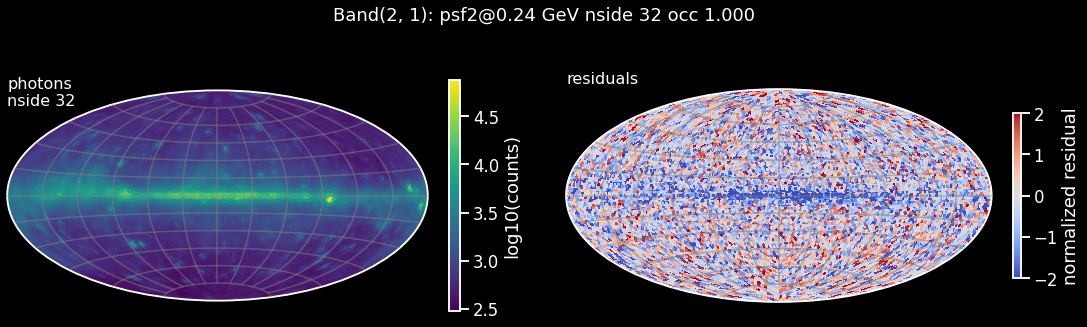

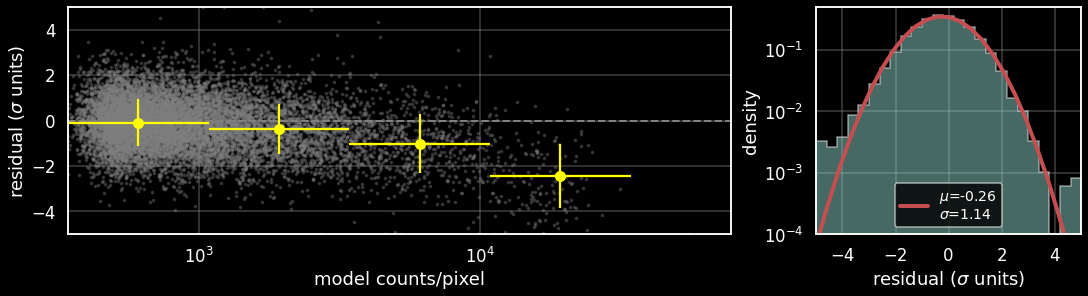

In [26]:
ResidualPlotter(pixel_table(2,1)).plots()

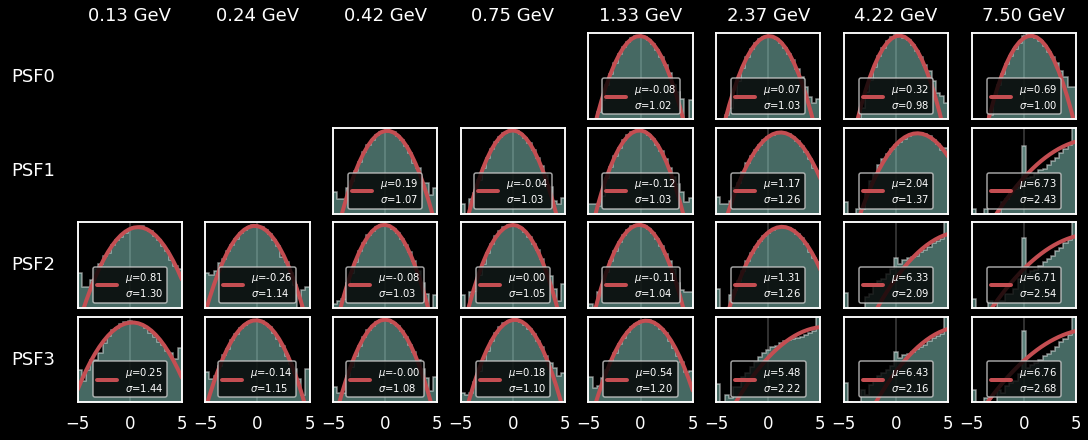

In [23]:
# assert False
multi_residual_plotter(pixel_table, nside=64)
# for i in range(0,6):
#     ResidualPlotter(pixel_table(2,i), 64).plots()
# for i in range(0,6):
#     ResidualPlotter(pixel_table(3,i)).plots()